## Data cleaning

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 5)

### load the dataset

In [2]:
df = pd.read_csv(
    "project_dataset.csv",
    sep=";",
    decimal=","
)

print("Shape:", df.shape)
df.head()

Shape: (12070, 26)


,Date,Service,Gare de départ,Gare d'arrivée,Durée moyenne du trajet,Nombre de circulations prévues,Nombre de trains annulés,Commentaire annulations,Nombre de trains en retard au départ,Retard moyen des trains en retard au départ,...,Nombre trains en retard > 15min,Retard moyen trains en retard > 15 (si liaison concurrencée par vol),Nombre trains en retard > 30min,Nombre trains en retard > 60min,Prct retard pour causes externes,Prct retard pour cause infrastructure,Prct retard pour cause gestion trafic,Prct retard pour cause matériel roulant,Prct retard pour cause gestion en gare et réutilisation de matériel,"Prct retard pour cause prise en compte voyageurs (affluence, gestions PSH, correspondances)"
0,2018-01,National,BORDEAUX ST JEAN,PARIS MONTPARNASSE,141.0,870,5.0,NaN,289.0,11.24780854,...,110.0,6.51,44.0,8.0,36.13445378,31.09243697,10.92436975,15.96638655,"5,04",0.840336134
1,2018-01,National,LE MANS,PARIS MONTPARNASSE,56.0,406.0,1.0,NaN,213.0,8.479968701,...,32.0,5.363539095,9.0,4.0,20.0,35.0,16.66666667,16.66666667,8.333333333,3.333333333
2,2018-01,National,PARIS MONTPARNASSE,LA ROCHELLE VILLE,166.0,226.0,0.0,NaN,21.0,6.23968254,...,11.0,2.938053097,6.0,1.0,22.22222222,27.77777778,16.66666667,16.66666667,5.555555556,11.11111111
3,2018-01,National,PARIS MONTPARNASSE,NANTES,216.21,508.0,3.0,NaN,71.0,7.235211268,...,39.0,5.292211221,18.0,NaN,33.33333333,22.22222222,16.66666667,20.37037037,5.555555556,1.851851852
4,2018-01,National,POITIERS,PARIS MONTPARNASSE,94.0,472.0,4.0,NaN,224.0,6.784672619,...,42.0,4.882371795,10.0,0.0,15.78947368,45.61403509,NaN,15.78947368,1.754385965,1.754385965


### inspect the data

In [3]:
print(df.info())

print("\nMissing values per column:")
print(df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12070 entries, 0 to 12069
Data columns (total 26 columns):
 #   Column                                                                                       Non-Null Count  Dtype 
---  ------                                                                                       --------------  ----- 
 0   Date                                                                                         12010 non-null  object
 1   Service                                                                                      11830 non-null  object
 2   Gare de départ                                                                               12011 non-null  object
 3   Gare d'arrivée                                                                               12011 non-null  object
 4   Durée moyenne du trajet                                                                      11830 non-null  object
 5   Nombre de circulations prévues         

### drop useless columns

In [4]:
columns_to_drop = [
    "Commentaire annulations",
    "Commentaire retards au départ",
    "Commentaire retards à l'arrivée",
    "Retard moyen trains en retard > 15 (si liaison concurrencée par vol)"
]

df = df.drop(columns=columns_to_drop)
print("Remaining columns:", df.shape[1])

Remaining columns: 22


### remove duplicates

In [5]:
print("Duplicates before:", df.duplicated().sum())
df = df.drop_duplicates()
print("Duplicates after:", df.duplicated().sum())

Duplicates before: 174
Duplicates after: 0


### standardize text columns : uppercase + strip

In [6]:
text_columns = ["Service", "Gare de départ", "Gare d'arrivée"]

for col in text_columns:
    df[col] = df[col].str.strip().str.upper()

print("Text standardized")
print(df[["Service", "Gare de départ", "Gare d'arrivée"]].head())

Text standardized
    Service      Gare de départ      Gare d'arrivée
0  NATIONAL    BORDEAUX ST JEAN  PARIS MONTPARNASSE
1  NATIONAL             LE MANS  PARIS MONTPARNASSE
2  NATIONAL  PARIS MONTPARNASSE   LA ROCHELLE VILLE
3  NATIONAL  PARIS MONTPARNASSE              NANTES
4  NATIONAL            POITIERS  PARIS MONTPARNASSE


### fix inconsistent station names

In [7]:
station_replacements = {
    "ANGERS ST LAUD": "ANGERS SAINT LAUD",
    "ST ETIENNE CHATEAUCREUX": "SAINT ETIENNE CHATEAUCREUX",
    "BORDEAUX ST JEAN": "BORDEAUX SAINT JEAN",
    "MARSEILLE ST CHARLES": "MARSEILLE SAINT CHARLES",
    "ST MALO": "SAINT MALO",
    "ST PIERRE DES CORPS": "SAINT PIERRE DES CORPS",
    "0": np.nan
}

df["Gare de départ"] = df["Gare de départ"].replace(station_replacements)
df["Gare d'arrivée"] = df["Gare d'arrivée"].replace(station_replacements)

print(f"Unique departure stations: {df['Gare de départ'].nunique()}")
print(f"Unique arrival stations: {df['Gare d\'arrivée'].nunique()}")

Unique departure stations: 59
Unique arrival stations: 59


### fix data types where we convert strings to numbers

In [8]:
numeric_columns = [
    "Durée moyenne du trajet",
    "Nombre de circulations prévues",
    "Nombre de trains annulés",
    "Nombre de trains en retard au départ",
    "Retard moyen des trains en retard au départ",
    "Retard moyen de tous les trains au départ",
    "Nombre de trains en retard à l'arrivée",
    "Retard moyen des trains en retard à l'arrivée",
    "Retard moyen de tous les trains à l'arrivée",
    "Nombre trains en retard > 15min",
    "Nombre trains en retard > 30min",
    "Nombre trains en retard > 60min",
    "Prct retard pour causes externes",
    "Prct retard pour cause infrastructure",
    "Prct retard pour cause gestion trafic",
    "Prct retard pour cause matériel roulant",
    "Prct retard pour cause gestion en gare et réutilisation de matériel",
    "Prct retard pour cause prise en compte voyageurs (affluence, gestions PSH, correspondances)"
]

for col in numeric_columns:
    df[col] = pd.to_numeric(df[col], errors="coerce")

print("types fixed")
df.dtypes

types fixed


Date                                                                                            object
Service                                                                                         object
Gare de départ                                                                                  object
Gare d'arrivée                                                                                  object
Durée moyenne du trajet                                                                        float64
Nombre de circulations prévues                                                                 float64
Nombre de trains annulés                                                                       float64
Nombre de trains en retard au départ                                                           float64
Retard moyen des trains en retard au départ                                                    float64
Retard moyen de tous les trains au départ                                

### feature engineering

In [9]:
def parse_date(date_str):
    if pd.isna(date_str):
        return pd.NaT
    date_str = str(date_str).strip()
    parts = date_str.replace("/", "-").replace(" ", "-").split("-")
    if len(parts[0]) == 2:
        date_str = f"{parts[1]}-{parts[0]}"
    else:
        date_str = "-".join(parts[:2])
    try:
        return pd.to_datetime(date_str, format="%Y-%m")
    except Exception:
        return pd.NaT

df["Date"] = df["Date"].apply(parse_date)

df["year"] = df["Date"].dt.year.astype("Int64")
df["month"] = df["Date"].dt.month.astype("Int64")

df["cancellation_rate"] = (
    df["Nombre de trains annulés"] / df["Nombre de circulations prévues"]
)

print("Feature engineering finished")
df[["Date", "year", "month", "cancellation_rate"]].head(10)

Feature engineering finished


,Date,year,month,cancellation_rate
0,2018-01-01,2018,1,0.005747
1,2018-01-01,2018,1,0.002463
2,2018-01-01,2018,1,0.000000
3,2018-01-01,2018,1,0.005906
4,2018-01-01,2018,1,0.008475
5,2018-01-01,2018,1,0.000000
6,2018-01-01,2018,1,0.000000
7,2018-01-01,2018,1,0.003597
8,2018-01-01,2018,1,0.004348
9,2018-01-01,2018,1,0.015228


### handle remaining missing values

In [10]:
for col in numeric_columns:
    if col in df.columns:
        df[col] = df[col].fillna(df[col].median())

df = df.dropna(subset=["Gare de départ", "Gare d'arrivée", "Date"])

print("Final shape after cleaning:", df.shape)
print("\nMissing values remaining:")
remaining = df.isnull().sum()
print(remaining[remaining > 0])

Final shape after cleaning: (11704, 25)

Missing values remaining:
Service              232
cancellation_rate    520
dtype: int64


### save cleaned dataset

In [11]:
df.to_csv("cleaned_dataset.csv", index=False)
print("cleaned_dataset.csv saved")
print(f"Final dataset: {df.shape[0]} rows, {df.shape[1]} columns")

cleaned_dataset.csv saved
Final dataset: 11704 rows, 25 columns


### summary statistics

In [12]:
df.describe()

/Users/mehdibenkhadra/Documents/EPITECH/TARDIS/B-DAT-200-LYN-2-1-tardis-6/venv/lib/python3.14/site-packages/pandas/core/nanops.py:1016: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)


,Date,Durée moyenne du trajet,Nombre de circulations prévues,Nombre de trains annulés,Nombre de trains en retard au départ,Retard moyen des trains en retard au départ,Retard moyen de tous les trains au départ,Nombre de trains en retard à l'arrivée,Retard moyen des trains en retard à l'arrivée,Retard moyen de tous les trains à l'arrivée,...,Nombre trains en retard > 60min,Prct retard pour causes externes,Prct retard pour cause infrastructure,Prct retard pour cause gestion trafic,Prct retard pour cause matériel roulant,Prct retard pour cause gestion en gare et réutilisation de matériel,"Prct retard pour cause prise en compte voyageurs (affluence, gestions PSH, correspondances)",year,month,cancellation_rate
count,11704,11704.000000,11704.000000,11704.000000,11704.000000,11704.000000,11704.000000,11704.000000,11704.000000,11704.000000,...,11704.000000,11704.000000,11704.000000,11704.000000,11704.000000,11704.000000,11704.000000,11704.0,11704.0,1.118400e+04
mean,2021-12-04 23:35:38.345864960,170.821566,269.933014,8.512389,86.213944,12.264172,3.115869,37.205485,35.175983,6.033700,...,5.101846,21.515900,21.840427,20.315072,18.846172,7.338975,7.516045,2021.469754,6.502392,inf
min,2018-01-01 00:00:00,0.000000,0.000000,0.000000,0.000000,0.000000,-229.269444,0.000000,-40.109259,-472.638889,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2018.0,1.0,0.000000e+00
25%,2019-12-01 00:00:00,101.000000,152.000000,0.000000,22.000000,6.307778,1.230993,15.000000,26.000092,3.454553,...,1.000000,10.804187,12.244898,10.638298,10.221475,0.000000,0.000000,2019.0,4.0,0.000000e+00
50%,2021-12-01 00:00:00,163.000000,229.000000,2.000000,52.000000,10.373750,2.330694,29.000000,33.460556,5.346154,...,3.000000,19.047619,20.000000,18.750000,17.085436,5.882353,5.000000,2021.0,7.0,7.017544e-03
75%,2023-12-01 00:00:00,221.000000,351.000000,7.000000,125.000000,15.502415,3.880151,50.000000,42.181049,7.987359,...,7.000000,29.411765,29.325815,28.070175,25.000000,10.845708,11.111111,2023.0,9.0,3.174603e-02
max,2025-12-01 00:00:00,786.000000,1100.000000,288.000000,1066.000000,316.188000,115.047390,376.000000,299.600000,92.000000,...,71.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,2025.0,12.0,inf
std,NaN,87.052794,180.548605,22.331206,89.905486,11.730455,5.131352,30.865723,15.520926,6.991014,...,5.879625,15.734095,14.711999,14.435925,13.358303,7.919652,9.346078,2.3112,3.447237,NaN


### distribution of average arrival delays

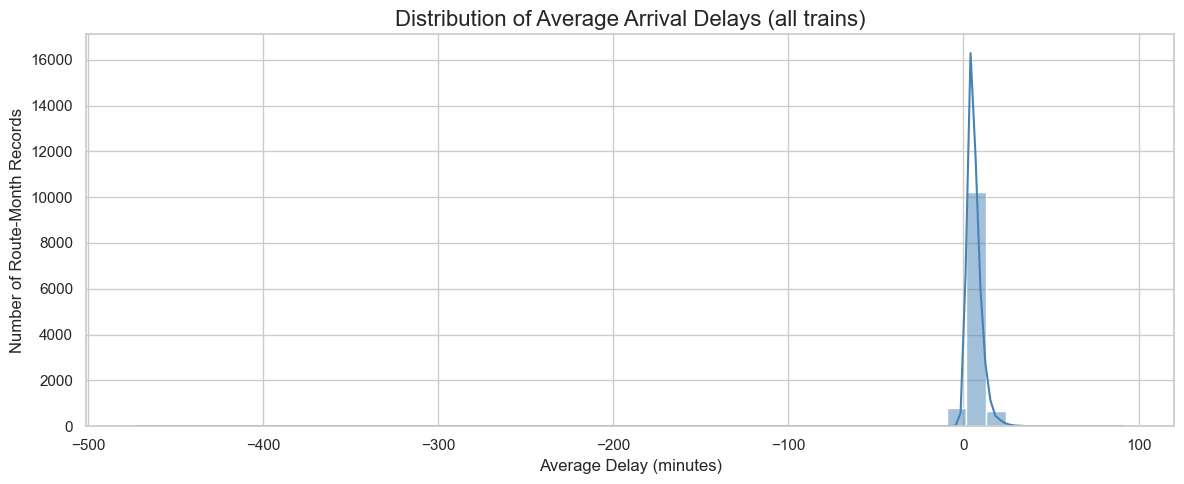

In [13]:
plt.figure(figsize=(12, 5))
sns.histplot(
    df["Retard moyen de tous les trains à l'arrivée"].dropna(),
    bins=50,
    color="steelblue",
    kde=True
)
plt.title("Distribution of Average Arrival Delays (all trains)", fontsize=16)
plt.xlabel("Average Delay (minutes)")
plt.ylabel("Number of Route-Month Records")
plt.tight_layout()
plt.show()

- most routes have an average arrival delay between 2 and 10 minutes
- very high delays (15+ min) are rare but do occur
- the concentration of delays in the 3 to 8 minute range

### top 10 most delayed departure stations

/var/folders/1k/1vk3t49j73b6527f6tdl9cr80000gn/T/ipykernel_93029/3800410276.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_delayed.values, y=top_delayed.index, palette="Reds_r")


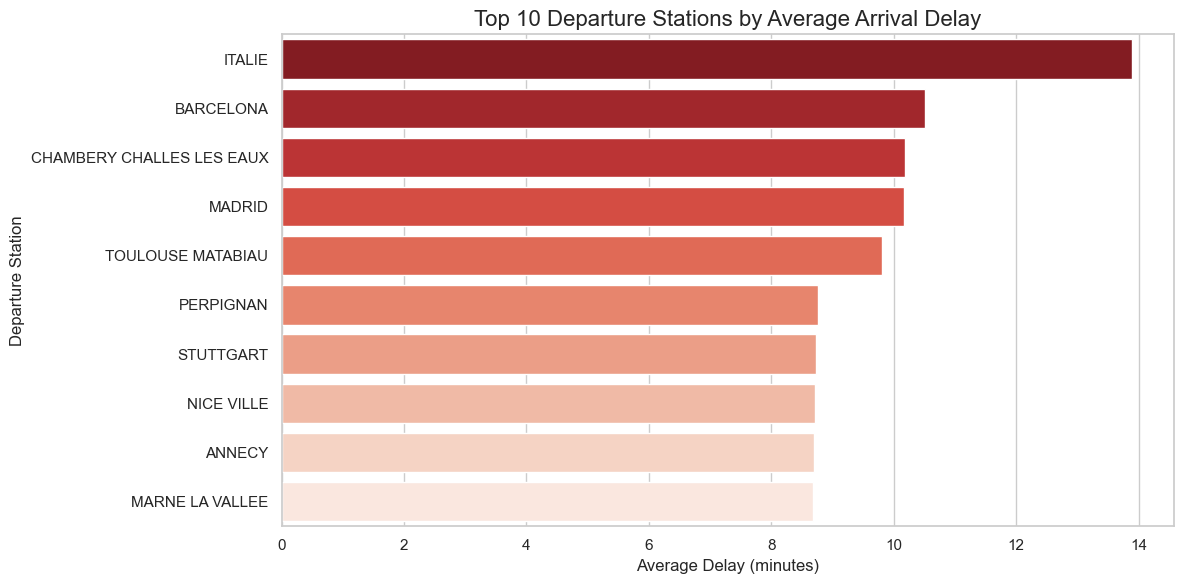

In [14]:
top_delayed = (
    df.groupby("Gare de départ")["Retard moyen de tous les trains à l'arrivée"]
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(12, 6))
sns.barplot(x=top_delayed.values, y=top_delayed.index, palette="Reds_r")
plt.title("Top 10 Departure Stations by Average Arrival Delay", fontsize=16)
plt.xlabel("Average Delay (minutes)")
plt.ylabel("Departure Station")
plt.tight_layout()
plt.show()

- international routes  tend to have higher average delays likely due to cross-border issues
- domestic routes and longer-distance trains show more delay variability

### average delay per year

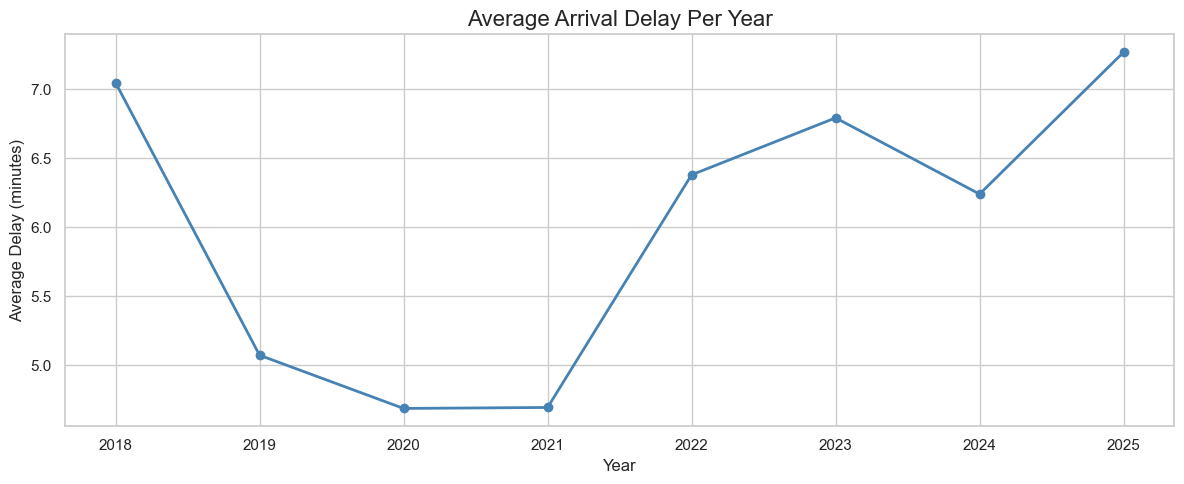

In [15]:
yearly_delay = df.groupby("year")["Retard moyen de tous les trains à l'arrivée"].mean()

plt.figure(figsize=(12, 5))
plt.plot(yearly_delay.index, yearly_delay.values, marker="o", color="steelblue", linewidth=2)
plt.title("Average Arrival Delay Per Year", fontsize=16)
plt.xlabel("Year")
plt.ylabel("Average Delay (minutes)")
plt.xticks(yearly_delay.index)
plt.tight_layout()
plt.show()

- the trend shows how external events like strikes, weather incidents, and infrastructure
investments have impacted delay levels over the years, notable spikes correspond to major disruption periods

### delay causes breakdown

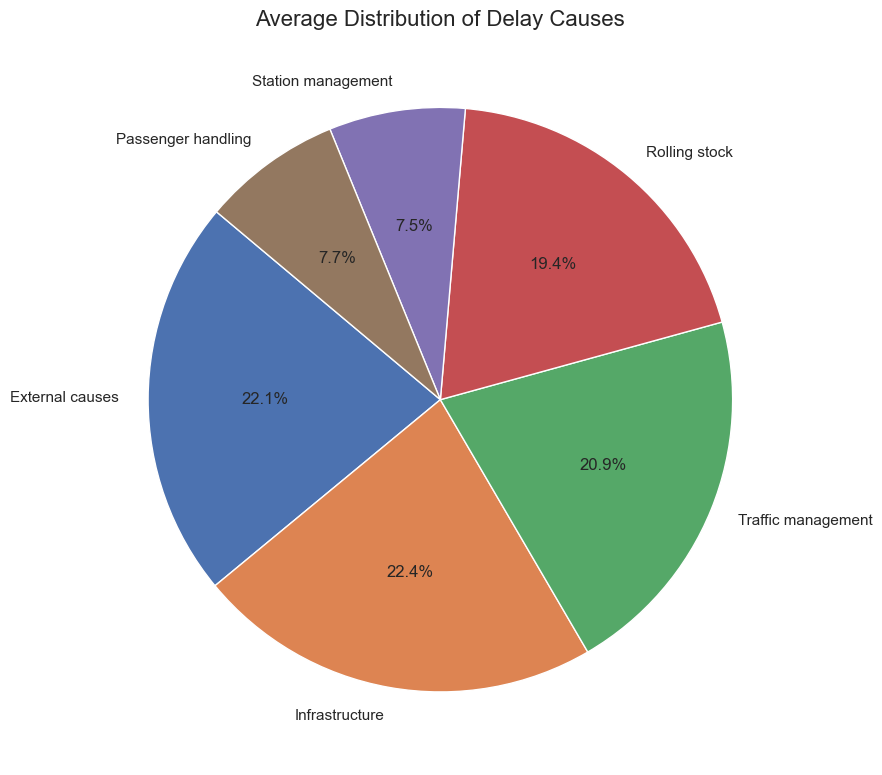

In [16]:
cause_cols = {
    "External causes": "Prct retard pour causes externes",
    "Infrastructure": "Prct retard pour cause infrastructure",
    "Traffic management": "Prct retard pour cause gestion trafic",
    "Rolling stock": "Prct retard pour cause matériel roulant",
    "Station management": "Prct retard pour cause gestion en gare et réutilisation de matériel",
    "Passenger handling": "Prct retard pour cause prise en compte voyageurs (affluence, gestions PSH, correspondances)"
}

cause_means = {
    label: df[col].mean()
    for label, col in cause_cols.items()
    if col in df.columns
}

plt.figure(figsize=(9, 9))
plt.pie(
    cause_means.values(),
    labels=cause_means.keys(),
    autopct="%1.1f%%",
    startangle=140
)
plt.title("Average Distribution of Delay Causes", fontsize=16)
plt.tight_layout()
plt.show()

- infrastructure and external causes together account for the majority of delays
- this is useful for SNCF management to prioritize where to invest in improvements